# Curated coursework artifact

This is the complete final HW4 notebook. It retains the original analytical narrative, reward design, SFT/GRPO methodology, and meaningful aggregate figures. Local data/model paths, checkpoint handling, raw completions, and per-example evaluation records have been removed; no work was rerun during curation.


#**PLEASE SAVE A COPY OF THIS NOTEBOOK TO SUBMIT**

# Modeling: MultiModal AI — Homework 4
**MAS.S60 / 6.S985 • Spring 2026 • MIT**

In this homework, you will explore **Reinforcement Learning for Vision-Language Models**. Specifically, you will implement and train a VLM using **Group Relative Policy Optimization (GRPO)**, a recent RL algorithm for aligning language models with reward signals.

---

## Environment Setup

Go to the top menu:
Runtime → Change runtime type → Hardware accelerator → Choose **"A100"**

If you do not have Colab Pro, you can sign up for a free student Colab Pro account here:
https://colab.research.google.com/signup

# Part 1: Reading & Reflection (20 points)

### Required Reading

1. [DeepSeekMath: Pushing the Limits of Mathematical Reasoning in Open Language Models](https://arxiv.org/abs/2402.03300) (Sections 1, 3, and 4)

2. [The Illustrated GRPO](https://abderrahmanskiredj.github.io/the-illustrated-grpo/) (Full post)

---

### Questions

1. **GRPO vs PPO**: GRPO removes the need for a learned value function (critic). Explain how GRPO estimates the baseline for advantage computation without a critic, and what tradeoffs this introduces.

2. **Reward Design**: Discuss the difference between using a learned reward model vs. a rule-based reward function (e.g., checking if an answer matches ground truth). What are the risks of reward hacking in each case?

3. **SFT vs. GRPO**: In Homework 3, you fine-tuned a VLM using supervised fine-tuning (SFT) with LoRA. Compare the SFT approach with GRPO training: how does the training signal differ, and when would each be preferred?

Please see the report of the homework.


# Part 2: Implementing and Training GRPO (100 points)

# Problem 1: GPU Verification and Library Installation

Run the following code cell to verify that your environment is correctly configured.

This step ensures that **PyTorch** and **CUDA** can access the GPU.
When the setup is correct, a **secret word** will appear in the output.

---

### In Your PDF Submission

Include:
- A **screenshot** or **code snippet** showing the printed GPU information.
- The **secret word** displayed by your verification cell.

---

In [4]:
!pip install transformers accelerate bitsandbytes pillow torch torchvision trl peft datasets gdown qwen-vl-utils matplotlib -q

import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
t = torch.randn(2, 3, device=device)
KEY = 73
cipher_bytes = [14, 27, 25, 6, 105, 32, 58, 105, 8, 37, 37, 105, 16, 38, 60, 105, 7, 44, 44, 45]

if t.is_cuda:
    cipher = torch.tensor(cipher_bytes, dtype=torch.uint8, device=device)
    decoded = cipher ^ KEY
    secret_word = "".join(chr(c) for c in decoded.cpu().tolist())
    print(f"\nGPU check passed! Secret word: {secret_word}")
else:
    print("\nNo GPU detected. Please switch to an A100 runtime.")

PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA device count: 1
GPU name: NVIDIA A100-SXM4-40GB

GPU check passed! Secret word: GRPO is All You Need


# Problem 2: Prepare Your Dataset (10 points)

You will **reuse the dataset you prepared in Homework 3** (or Homework 1/2). The data format remains the same:

```
mmai-data/
├── images/
│   ├── image_01.jpg
│   └── ...
└── data.jsonl
```

Each line in `data.jsonl` should be a JSON object with:

```json
{
  "image": "images/1.jpg",
  "question": "What animal is in this image?",
  "answer": "cat"
}
```

**Homework 3 + Google Drive:** If you saved data in Colab like HW3 (`My Drive` → `HW3_outputs` → `mmai-data` with `images/` and `data*.jsonl`), the next code cell can **mount Drive and copy** that folder to `./mmai-data` (same layout this homework expects). If the Drive path is missing or you are not in Colab, it **falls back** to downloading a zip via `gdown`.

**If you do not have your own dataset**, the default Google Drive link in the fallback will download a small example dataset so you can complete the homework. You will lose some points for not using your own data, but you can still finish every problem.

As in HW3, you should have a **train/test split**. The test images should not be used during training.

In HW3, you used supervised fine-tuning (SFT), which directly trains the model to produce the correct answer. In this homework, we use **reinforcement learning**: the model generates its own answers, receives a reward signal, and updates its policy to maximize future reward.

To enable the RL training loop, we append an instruction after each user question asking the model to **think step-by-step** and then place its final answer after `Answer:`. This structured output lets us automatically extract and evaluate the model's prediction.

In [5]:
import os, shutil, zipfile, json
from pathlib import Path

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# HW3 Colab workflow: full mmai-data is under
#   My Drive / HW3_outputs / mmai-data /
# (jsonl files + images/). Set USE_GOOGLE_DRIVE = True in Colab to copy
# that folder into ./mmai-data before anything else.
#
# If Drive copy is skipped or fails, we fall back to gdown + zip (your own
# share link, or the course default example below).

USE_GOOGLE_DRIVE: bool = True
HW3_DRIVE_MMAI: Path = Path("<Google Drive path removed>")

GDRIVE_SHARE_URL = None  # External dataset URL omitted from the public artifact.

# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

DATA_ROOT = Path("mmai-data")
ZIP_PATH = Path("mmai-data.zip")


def _dataset_ready(root: Path) -> bool:
    return root.is_dir() and (root / "data.jsonl").is_file()


def _copy_hw3_mmai_from_drive() -> bool:
    """Same source as HW3 notebook: mount Drive, copy HW3_outputs/mmai-data -> ./mmai-data."""
    try:
        from google.colab import drive
    except ImportError:
        print("Not in Google Colab — skipping Drive. Use ./mmai-data locally or gdown fallback.")
        return False
    print("Mounting Google Drive (HW3 layout)...")
# Curation note: Drive mounting omitted from the public static artifact.
    if not HW3_DRIVE_MMAI.is_dir():
        print(f"Not found on Drive: {HW3_DRIVE_MMAI}")
        return False
    if not (HW3_DRIVE_MMAI / "data.jsonl").is_file():
        print(f"No data.jsonl at {HW3_DRIVE_MMAI}")
        return False
    if DATA_ROOT.exists():
        shutil.rmtree(DATA_ROOT)
    shutil.copytree(HW3_DRIVE_MMAI, DATA_ROOT)
    img_dir = DATA_ROOT / "images"
    n_img = len(list(img_dir.glob("*"))) if img_dir.is_dir() else 0
    print(f"Copied {HW3_DRIVE_MMAI} -> {DATA_ROOT.resolve()} ({n_img} files under images/)")
    return True


if not _dataset_ready(DATA_ROOT):
    loaded = False
    if USE_GOOGLE_DRIVE:
        loaded = _copy_hw3_mmai_from_drive()
    if not loaded and not _dataset_ready(DATA_ROOT):
GDRIVE_SHARE_URL = None  # External dataset URL omitted from the public artifact.
            print("Falling back to gdown (zip)...")
            import gdown
# Curation note: external dataset download omitted from the public static artifact.
            with zipfile.ZipFile(ZIP_PATH) as zf:
                zf.extractall(".")
            ZIP_PATH.unlink(missing_ok=True)
        else:
GDRIVE_SHARE_URL = None  # External dataset URL omitted from the public artifact.
else:
    print(f"Using existing dataset at {DATA_ROOT.resolve()}")

# Verify dataset
if _dataset_ready(DATA_ROOT):
    jsonl_path = DATA_ROOT / "data.jsonl"
    train_path = DATA_ROOT / "data_train.jsonl"
    test_path = DATA_ROOT / "data_test.jsonl"
    with open(jsonl_path) as f:
        lines = [json.loads(l) for l in f if l.strip()]
    # Same rule as Problem 6: prefer train split for integrity of training data
    grpo_path = train_path if train_path.is_file() else jsonl_path
    with open(grpo_path) as f:
        grpo_lines = [json.loads(l) for l in f if l.strip()]
    img_dir = DATA_ROOT / "images"
    n_img = len(list(img_dir.glob("*"))) if img_dir.is_dir() else 0
    if n_img == 0:
        print("Warning: images/ is missing or empty; check Drive copy or zip contents.")
    missing_img = sum(
        1 for row in grpo_lines if not (DATA_ROOT / row["image"]).is_file()
    )
    if missing_img:
        print(
            f"Warning: {missing_img} rows in {grpo_path.name} point to missing files under {DATA_ROOT}."
        )
    else:
        print(
            f"Integrity check: all image paths in {grpo_path.name} exist on disk ({len(grpo_lines)} rows)."
        )
    if train_path.is_file() and test_path.is_file():
        print(
            "Note: data_train.jsonl / data_test.jsonl found — Problem 6 trains on data_train.jsonl only."
        )
    print(f"data.jsonl: {len(lines)} rows (metadata / legacy). GRPO will use {grpo_path.name} ({len(grpo_lines)} rows).")
    print(f"Files under images/: {n_img}")
    print(f"Sample: {grpo_lines[0]}")
else:
    print("Dataset not found. Use HW3 Drive path, gdown zip, or upload ./mmai-data.")

External dataset acquisition and sample records are omitted. Archived integrity checks reported 366 training rows and 458 images.


# Problem 3: Understanding GRPO (15 points)

Before implementing GRPO, let us walk through the key ideas.

## Background: From PPO to GRPO

Standard RLHF methods like **PPO (Proximal Policy Optimization)** require four models: a policy, a reference model, a reward model, and a value model (critic). GRPO simplifies this by **removing the value model entirely**, using the group of completions generated for the same prompt to estimate a baseline.

## The GRPO Algorithm

Given a prompt $q$, we sample $G$ completions $\{o_1, o_2, \ldots, o_G\}$ from the current policy $\pi_\theta$. Each completion receives a reward $r_i$.

### Step 1: Compute the Group Advantage

$$\hat{A}_i = \frac{r_i - \text{mean}(\mathbf{r})}{\text{std}(\mathbf{r}) + \epsilon}$$

where $\mathbf{r} = [r_1, \ldots, r_G]$ are the rewards for all completions of the same prompt.

### Step 2: Clipped Surrogate Loss

$$L_{\text{GRPO}}(\theta) = -\frac{1}{G} \sum_{i=1}^{G} \frac{1}{|o_i|} \sum_{t=1}^{|o_i|} \min\left( \rho_{i,t} \hat{A}_i,\ \text{clip}(\rho_{i,t},\ 1 - \varepsilon,\ 1 + \varepsilon) \hat{A}_i \right)$$

where $\rho_{i,t} = \frac{\pi_\theta(o_{i,t} | q, o_{i,<t})}{\pi_{\theta_{\text{old}}}(o_{i,t} | q, o_{i,<t})}$ is the importance sampling ratio.

### Step 3 (Optional): KL Regularization

$$L_{\text{total}} = L_{\text{GRPO}} + \beta \cdot \mathbb{D}_{\text{KL}}[\pi_\theta \| \pi_{\text{ref}}]$$

---

## Questions to Answer:

1. In your own words, explain why the group-based advantage normalization works as a baseline. What happens when all $G$ completions for a prompt receive the same reward?

2. What is the role of the clipping term $\text{clip}(\rho_{i,t}, 1-\varepsilon, 1+\varepsilon)$? What could go wrong during training without it?

---


Please see the report of the homework.

# Problem 4: Implement the GRPO Advantage Computation (25 points)

In this problem, you will implement the core of the GRPO algorithm: the **group-relative advantage computation**.

The function below receives:
- `rewards`: a tensor of shape `(batch_size,)` containing the scalar reward for each completion
- `group_ids`: a numpy array of shape `(batch_size,)` where entries with the same value belong to the same prompt group
- `response_mask`: a tensor of shape `(batch_size, response_length)` indicating which tokens are real (1) vs. padding (0)

Your task is to fill in the parts marked `# TODO`. Unit tests will run automatically to verify your implementation.

---

### Example

```python
# Two prompts, each with 2 completions (G=2), response length = 3
rewards    = torch.tensor([1.0, 3.0, 2.0, 4.0])
group_ids  = np.array([0, 0, 1, 1])         # samples 0,1 share prompt 0; samples 2,3 share prompt 1
mask       = torch.ones(4, 3)

result = compute_grpo_advantage(rewards, group_ids, mask)
# result shape: (4, 3)
# Group 0 mean=2.0, std=1.41 → sample 0 advantage ≈ -0.71, sample 1 advantage ≈ +0.71
# Group 1 mean=3.0, std=1.41 → sample 2 advantage ≈ -0.71, sample 3 advantage ≈ +0.71
# Each scalar advantage is broadcast across the 3 token positions, masked by response_mask.
```

In [1]:
import torch
import numpy as np
from collections import defaultdict

def compute_grpo_advantage(
    rewards: torch.Tensor,
    group_ids: np.ndarray,
    response_mask: torch.Tensor,
    epsilon: float = 1e-6,
    scale_by_std: bool = True,
) -> torch.Tensor:
    """
    Compute group-relative advantages for GRPO.

    Args:
        rewards: (batch_size,) scalar reward per completion
        group_ids: (batch_size,) integer group ID per completion
            (completions sharing a group_id came from the same prompt)
        response_mask: (batch_size, response_length) binary mask
        epsilon: small constant to avoid division by zero
        scale_by_std: if True, divide by group std (original GRPO);
                      if False, only subtract group mean (Dr. GRPO variant)

    Returns:
        advantages: (batch_size, response_length) per-token advantages
    """
    batch_size = rewards.shape[0]
    advantages = torch.zeros_like(rewards)

    # ============================================================
    # ######################## CHANGE ME #########################
    # ============================================================

    # Step 1: Group the rewards by group_ids.
    id_to_rewards = defaultdict(list)
    for i in range(batch_size):
        gid = int(group_ids[i])
        id_to_rewards[gid].append(rewards[i].item())

    # Step 2: Compute the mean and standard deviation of rewards within each group.
    id_to_mean = {}
    id_to_std = {}
    for gid, rlist in id_to_rewards.items():
        t = torch.tensor(rlist, dtype=rewards.dtype, device=rewards.device)
        id_to_mean[gid] = t.mean().item()
        if len(rlist) == 1:
            id_to_std[gid] = 1.0
        else:
            id_to_std[gid] = t.std(unbiased=True).item()

    # Step 3: Normalize rewards within each group to get per-sample advantages. 
    for i in range(batch_size):
        gid = int(group_ids[i])
        mean = id_to_mean[gid]
        if scale_by_std:
            advantages[i] = (rewards[i] - mean) / (id_to_std[gid] + epsilon)
        else:
            advantages[i] = rewards[i] - mean

    # ============================================================
    # ###################### END CHANGE ME #######################
    # ============================================================

    # Step 4: Broadcast scalar advantages to token level.
    per_token_advantages = advantages.unsqueeze(-1) * response_mask

    return per_token_advantages


# ==================== Unit Tests ====================
# Do NOT modify this section.

def test_grpo_advantage():
    print("Running tests...")

    # Test 1: Basic two-group case
    rewards = torch.tensor([1.0, 3.0, 2.0, 4.0])
    group_ids = np.array([0, 0, 1, 1])
    mask = torch.ones(4, 5)
    adv = compute_grpo_advantage(rewards, group_ids, mask, scale_by_std=True)
    assert adv.shape == (4, 5), f"Expected shape (4, 5), got {adv.shape}"
    assert adv[0, 0] < 0, "Sample 0 should have negative advantage (below group mean)"
    assert adv[1, 0] > 0, "Sample 1 should have positive advantage (above group mean)"
    print("  Test 1 passed: basic two-group case")

    # Test 2: Single-sample group should have zero advantage
    rewards = torch.tensor([5.0, 1.0, 3.0])
    group_ids = np.array([0, 1, 1])
    mask = torch.ones(3, 4)
    adv = compute_grpo_advantage(rewards, group_ids, mask, scale_by_std=True)
    assert torch.allclose(adv[0], torch.zeros(4)), "Single-sample group should have zero advantage"
    print("  Test 2 passed: single-sample group")

    # Test 3: Masking zeros out padded positions
    rewards = torch.tensor([1.0, 3.0])
    group_ids = np.array([0, 0])
    mask = torch.tensor([[1, 1, 0, 0], [1, 1, 1, 0]], dtype=torch.float)
    adv = compute_grpo_advantage(rewards, group_ids, mask, scale_by_std=True)
    assert adv[0, 2] == 0.0 and adv[1, 3] == 0.0, "Padded positions should be 0"
    assert adv[1, 0] != 0.0, "Non-padded position should be non-zero"
    print("  Test 3 passed: masking")

    # Test 4: Dr. GRPO variant (no std scaling)
    rewards = torch.tensor([1.0, 3.0])
    group_ids = np.array([0, 0])
    mask = torch.ones(2, 3)
    adv = compute_grpo_advantage(rewards, group_ids, mask, scale_by_std=False)
    assert torch.allclose(adv[0], torch.full((3,), -1.0)), f"Expected -1.0, got {adv[0]}"
    assert torch.allclose(adv[1], torch.full((3,), 1.0)), f"Expected +1.0, got {adv[1]}"
    print("  Test 4 passed: Dr. GRPO variant")

    # Test 5: Uniform rewards -> zero advantage
    rewards = torch.tensor([2.0, 2.0, 2.0])
    group_ids = np.array([0, 0, 0])
    mask = torch.ones(3, 4)
    adv = compute_grpo_advantage(rewards, group_ids, mask, scale_by_std=True)
    assert torch.allclose(adv, torch.zeros(3, 4), atol=1e-5), "Same rewards should give zero advantage"
    print("  Test 5 passed: uniform rewards")

    print("\nAll tests passed!")

test_grpo_advantage()

Running tests...
  Test 1 passed: basic two-group case
  Test 2 passed: single-sample group
  Test 3 passed: masking
  Test 4 passed: Dr. GRPO variant
  Test 5 passed: uniform rewards

All tests passed!


# Problem 5: Define Reward Functions (15 points)

Now you will define the reward functions used to train the model. We use two simple, rule-based rewards:

1. **Accuracy Reward** (binary): Does the model's answer match the ground truth? We extract the answer from after `Answer:` and compare.

2. **Format Reward** (binary): Did the model use the `Answer:` format at all? This gives a learning signal even when the answer is wrong, preventing the reward from being zero everywhere early in training.
**Extension (MILP dataset):** The reference implementation uses **partial credit** when both prediction and ground truth parse as MILP summary lines: we award the fraction of matching fields (6 fields) instead of a strict 0/1. This yields a **smoother learning signal** for GRPO than a purely binary accuracy reward, while `format_reward` remains binary on whether a parsable `Answer:` / summary line exists.

Fill in the parts marked `# TODO`. The `extract_answer` helper is provided for you.

---

### Reward Function API

The GRPOTrainer calls your reward functions with the following signature:

```python
def my_reward_func(completions: list, **kwargs) -> list:
```

**`completions`** is a list of model completions, one per sample. Each completion is a
single-element list containing a message dict:

```python
# completions example (batch of 3):
[
    [{"role": "assistant", "content": "Let me think step by step...\nAnswer: cat"}],
    [{"role": "assistant", "content": "I see a vehicle.\nAnswer: truck"}],
    [{"role": "assistant", "content": "This looks like a park."}],
]
```

To get the text, use `completion[0]["content"]`.

**`**kwargs`** contains any extra dataset columns. For example, the `answer` column
from the dataset is passed as `answer=["cat", "truck", "dog"]`.

**Return**: a `list[float]` of the same length as `completions`, with one reward per sample.

In [ ]:
import re

_MILP_LINE = re.compile(
    r"(Variables:\s*\d+,\s*Constraints:\s*\d+,\s*Density:\s*\w+,\s*"
    r"Binary:\s*[\d.]+%,\s*Integer:\s*[\d.]+%,\s*Objective:\s*\w+)",
    re.IGNORECASE | re.DOTALL,
)


def extract_answer(text: str):
    # First try to find the "Answer:" marker that we asked for in the prompt
    text = text.strip()
    match = re.search(r"Answer:\s*(.+)", text, re.IGNORECASE | re.DOTALL)
    if match:
        rest = match.group(1).strip()
        # CoT allowed before Answer:; take first non-empty line after Answer: for scoring.
        for line in rest.splitlines():
            line = line.strip()
            if line:
                return line
        return rest
    m2 = _MILP_LINE.search(text)
    if m2:
        return m2.group(1).strip()
    return None


def parse_milp_fields(s: str):
    # Pull out the 6 specific values into a tuple
    m = re.search(
        r"Variables:\s*(\d+),\s*Constraints:\s*(\d+),\s*Density:\s*(\w+),\s*"
        r"Binary:\s*([\d.]+%),\s*Integer:\s*([\d.]+%),\s*Objective:\s*(\w+)",
        s,
        re.I | re.DOTALL,
    )
    return m.groups() if m else None


def milp_per_field_correct(pred: str | None, gt: str):
    """List of 6 bools if both pred and gt parse as MILP lines; else None."""
    if pred is None:
        return None
    rewards = torch.tensor([5.0, 1.0, 3.0])
    group_ids = np.array([0, 1, 1])
    mask = torch.ones(3, 4)
    adv = compute_grpo_advantage(rewards, group_ids, mask, scale_by_std=True)
    assert torch.allclose(adv[0], torch.zeros(4)), "Single-sample group should have zero advantage"

MILP_FIELD_NAMES = ["Variables", "Constraints", "Density", "Binary", "Integer", "Objective"]



def accuracy_reward(completions: list, answer: list, **kwargs) -> list:

    # ============================================================
    # ######################## CHANGE ME #########################
    # ============================================================

    def _milp_fields(s: str):
        return parse_milp_fields(s)
    
    # Helper to check if a string looks like our MILP format at a glance
    def _looks_milp(s: str) -> bool:
        return "Variables:" in s and "Constraints:" in s and "Objective:" in s
    
    # Give partial credit (1/6 point per matching field) instead of strict 0/1
    def _milp_field_score(pred: str, gt: str) -> float:
        pp, gg = _milp_fields(pred), _milp_fields(gt)
        if not pp or not gg:
            return 0.0
        return sum(
            1 for a, b in zip(pp, gg) if a.strip().lower() == b.strip().lower()
        ) / 6.0

    rewards = []
    for completion, gt in zip(completions, answer):
        text = completion[0]["content"]
        pred = extract_answer(text)
        if pred is None:
            rewards.append(0.0)
        elif pred == gt:
            rewards.append(1.0)
        elif _looks_milp(gt) and _looks_milp(pred):
            rewards.append(_milp_field_score(pred, gt))
        else:
            rewards.append(0.0)

    # ============================================================
    # ###################### END CHANGE ME #######################
    # ============================================================
    return rewards


def format_reward(completions: list, **kwargs) -> list:
    
    # ============================================================
    # ######################## CHANGE ME #########################
    # ============================================================

    rewards = []
    for completion in completions:
        text = completion[0]["content"]
        rewards.append(1.0 if extract_answer(text) is not None else 0.0)

    # ============================================================
    # ###################### END CHANGE ME #######################
    # ============================================================
    return rewards


# ==================== Unit Tests ====================

def test_reward_functions():
    print("Running reward function tests...")

    assert extract_answer("I think it is a dog. Answer: dog") == "dog"
    assert extract_answer("No answer marker here") is None
    milp_line = (
        "Variables: 2, Constraints: 2, Density: high, Binary: 0%, Integer: 100%, Objective: minimize"
    )
    assert extract_answer(milp_line) == milp_line
    assert extract_answer("Some reasoning first.\n" + milp_line) == milp_line
    print("  extract_answer: passed")

    completions_conv = [
        [{"role": "assistant", "content": "Let me think... Answer: 42"}],
        [{"role": "assistant", "content": "The result is Answer: wrong"}],
        [{"role": "assistant", "content": "No answer marker"}],
    ]
    gt = ["42", "correct", "anything"]
    rewards = accuracy_reward(completions=completions_conv, answer=gt)
    assert rewards == [1.0, 0.0, 0.0], f"Expected [1.0, 0.0, 0.0], got {rewards}"
    milp_gt = (
        "Variables: 4, Constraints: 5, Density: high, Binary: 0%, Integer: 50%, Objective: minimize"
    )
    r_exact = accuracy_reward(
        [[{"role": "assistant", "content": f"Answer: {milp_gt}"}]], [milp_gt]
    )
    assert r_exact == [1.0], r_exact
    r_partial = accuracy_reward(
        [
            [
                {
                    "role": "assistant",
                    "content": "Answer: Variables: 4, Constraints: 5, Density: low, Binary: 0%, Integer: 50%, Objective: minimize",
                }
            ]
        ],
        [milp_gt],
    )[0]
    assert 0.0 < r_partial < 1.0, r_partial
    print("  accuracy_reward: passed")

    completions_fmt = [
        [{"role": "assistant", "content": "Answer: hello"}],
        [{"role": "assistant", "content": "no answer marker here"}],
        [{"role": "assistant", "content": milp_line}],
    ]
    rewards = format_reward(completions=completions_fmt)
    assert rewards == [1.0, 0.0, 1.0], f"Expected [1.0, 0.0, 1.0], got {rewards}"
    print("  format_reward: passed")

    print("\nAll reward function tests passed!")

test_reward_functions()


Running reward function tests...
  extract_answer: passed
  accuracy_reward: passed
  format_reward: passed

All reward function tests passed!


# Problem 6: Build the Training Dataset for GRPO (10 points)

Now we convert your training jsonl into the format expected by the TRL `GRPOTrainer`. If `data_train.jsonl` exists (HW3 layout), it is used; otherwise `data.jsonl`.

The trainer needs a HuggingFace `Dataset` with a `prompt` column (conversational messages), an `image` column, and an `answer` column (passed through to the reward functions).

We append an **instruction suffix** after each user question that tells the model to think step-by-step and output its final answer after `Answer:`.
**Instruction suffix:** Step-by-step reasoning with five cues (X/Y matrix blocks, density, **vtype** row + legend, objective and **coefficient of obj** / inequalities), then one `Answer:` line matching jsonl. Keep max tokens high enough (Problems 7 and 8).

The code builds a **multimodal** user message (`image` placeholder + `text`) when `USE_MULTIMODAL_USER_MESSAGE` is `True`, which matches the TRL + Qwen-VL GRPO pattern; you can set it to `False` to use a plain-text user message plus the separate `image` column.

In [8]:
import json
from pathlib import Path
from PIL import Image
from datasets import Dataset

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
DATA_ROOT = Path("mmai-data")

# Appended to each question — must match jsonl labels (extract after \"Answer:\").
INSTRUCTION_SUFFIX = (
    "\n\nBefore providing your final answer, you MUST write down your visual reasoning step-by-step. "
    "Look at the provided MILP heatmap and explicitly answer these five questions:\n"
    "1. Variables: Count individual blocks or columns along the X-axis (horizontal) in the main matrix — what is "
    "the total number of variables? Cross-check tick marks or labels if visible.\n"
    "2. Constraints: Count individual blocks or rows along the Y-axis (vertical) in the main matrix — what is the "
    "total number of constraints?\n"
    "3. Density: Look at the overall main matrix grid. From colored blocks versus empty space, is density low, medium, or high?\n"
    "4. Variable types: Look at the bottom row labeled 'vtype' and its legend. From the colors shown, estimate "
    "the percentage of Binary variables and Integer variables.\n"
    "5. Objective: Look at the rightmost section (e.g. inequality signs <=, >=, or == next to 'coefficient of obj'). "
    "Is it minimize or maximize?\n\n"
    "After all five steps, output exactly ONE final line. It must start with \"Answer:\" and then use the "
    "SAME format as the dataset answer field (the text after \"Answer:\" must look like: "
    "Variables: <int>, Constraints: <int>, Density: low|medium|high, Binary: <int>%, Integer: <int>%, Objective: minimize|maximize).\n"
    "Pattern example (illustrative numbers only — yours must match the image):\n"
    "Answer: Variables: 4, Constraints: 5, Density: high, Binary: 0%, Integer: 50%, Objective: minimize\n"
    "Full example — reasoning lines, then the final line repeated in that exact answer format:\n"
    "1. Variables: I count 4 variable columns along the X-axis in the main matrix.\n"
    "2. Constraints: I count 5 constraint rows along the Y-axis.\n"
    "3. Density: most cells are nonzero — high.\n"
    "4. Variable types: from the vtype row and legend I estimate Binary 0% and Integer 50%.\n"
    "5. Objective: the objective / coefficient-of-obj inequalities indicate minimize.\n"
    "Answer: Variables: 4, Constraints: 5, Density: high, Binary: 0%, Integer: 50%, Objective: minimize"
)

# TRL + Qwen-VL: use multimodal user message (image placeholder + text). Set False to use plain text user content only.
USE_MULTIMODAL_USER_MESSAGE = True

# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================


def build_grpo_dataset(data_root: Path, instruction_suffix: str) -> Dataset:
    """Build a HuggingFace Dataset for GRPO: columns prompt, image, answer (train split preferred)."""
    train_jsonl = data_root / "data_train.jsonl"
    jsonl_path = train_jsonl if train_jsonl.is_file() else data_root / "data.jsonl"
    if not jsonl_path.is_file():
        raise FileNotFoundError(f"Need {data_root / 'data_train.jsonl'} or {data_root / 'data.jsonl'}")
    print(f"Building GRPO dataset from: {jsonl_path.name}")
    with open(jsonl_path) as f:
        raw_data = [json.loads(line) for line in f if line.strip()]

    samples = {"prompt": [], "image": [], "answer": []}
    skipped = 0

    for entry in raw_data:
        img_path = data_root / entry["image"]
        if not img_path.exists():
            print(f"Warning: image not found: {img_path}")
            skipped += 1
            continue

        image = Image.open(img_path).convert("RGB")
        text = entry["question"] + instruction_suffix

        if USE_MULTIMODAL_USER_MESSAGE:
            prompt = [
                {
                    "role": "user",
                    "content": [
                        {"type": "image"},
                        {"type": "text", "text": text},
                    ],
                },
            ]
        else:
            prompt = [{"role": "user", "content": text}]

        samples["prompt"].append(prompt)
        samples["image"].append(image)
        samples["answer"].append(entry["answer"])

    if not samples["prompt"]:
        raise ValueError(
            "No training rows loaded — check mmai-data paths, images/, and jsonl."
        )
    if skipped:
        print(f"Skipped {skipped} rows with missing image files.")

    dataset = Dataset.from_dict(samples)
    print(f"Built dataset with {len(dataset)} samples")
    return dataset


dataset = build_grpo_dataset(DATA_ROOT, INSTRUCTION_SUFFIX)
print(f"Columns: {dataset.column_names}")
print(f"Sample prompt roles: {[m['role'] for m in dataset[0]['prompt']]}")
c0 = dataset[0]['prompt'][0]['content']
print(f"First user content is list (multimodal): {isinstance(c0, list)}")


Building GRPO dataset from: data_train.jsonl
Built dataset with 366 samples
Columns: ['prompt', 'image', 'answer']
Sample prompt roles: ['user']
First user content is list (multimodal): True


# Problem 6.5 (optional): Supervised fine-tuning (SFT) before GRPO

**Why:** GRPO from a cold-started LoRA can be unstable or slow to improve exact-match accuracy. A short **SFT** phase on the same `(image, question, answer)` data teaches the model the task format and label style; **GRPO** then refines the policy with reward signals.

**Master switch `USE_SFT` (in the code cell below):** Default **`False`** — SFT is **disabled** and the homework runs **pure GRPO** from a fresh LoRA on the base model (cold start). Set **`USE_SFT = True`** only if you intentionally want an SFT warmup; then **Problem 7** will load `sft-output/` when present.
**Second switch `SFT_ONLY_BASELINE_RUN` (same code cell):** Set **`True`** to run **Problem 6.5 SFT only** and **skip Problem 7 GRPO** entirely. Use this to populate SFT checkpoints for **Problem 8.2 (continued)** without a long GRPO run. For **SFT warmup → GRPO**, set **`SFT_ONLY_BASELINE_RUN = False`**. Requires **`USE_SFT = True`**.

**Artifact folders:** All run outputs go under `hw4_run_data/cold_grpo/`, `hw4_run_data/sft_then_grpo/`, or `hw4_run_data/sft_only/` depending on `USE_SFT` and `SFT_ONLY_BASELINE_RUN`, so different switch combinations do not overwrite each other.
**Second switch `SFT_ONLY_BASELINE_RUN` (same code cell):** Set **`True`** to run **Problem 6.5 SFT only** and **skip Problem 7 GRPO** entirely. Use this to populate SFT checkpoints for **Problem 8.2 (continued)** without a long GRPO run. For **SFT warmup → GRPO**, set **`SFT_ONLY_BASELINE_RUN = False`**. Requires **`USE_SFT = True`**.

**Artifact folders:** All run outputs go under `hw4_run_data/cold_grpo/`, `hw4_run_data/sft_then_grpo/`, or `hw4_run_data/sft_only/` depending on `USE_SFT` and `SFT_ONLY_BASELINE_RUN`, so different switch combinations do not overwrite each other.
**Second switch `SFT_ONLY_BASELINE_RUN` (same code cell):** Set **`True`** to run **Problem 6.5 SFT only** and **skip Problem 7 GRPO** entirely. Use this to populate SFT checkpoints for **Problem 8.2 (continued)** without a long GRPO run. For **SFT warmup → GRPO**, set **`SFT_ONLY_BASELINE_RUN = False`**. Requires **`USE_SFT = True`**.

**Artifact folders:** All run outputs go under `hw4_run_data/cold_grpo/`, `hw4_run_data/sft_then_grpo/`, or `hw4_run_data/sft_only/` depending on `USE_SFT` and `SFT_ONLY_BASELINE_RUN`, so different switch combinations do not overwrite each other.

**HW3 checkpoint:** If you already have a LoRA folder trained on **`Qwen/Qwen3-VL-2B-Instruct`** with the **same** `target_modules` / rank as below, you can point `SFT_ADAPTER_PATH` there in Problem 7 (with `USE_SFT = True`).

**Note:** Adapters trained on **Qwen2.5-VL** (HW3 default) are **not** compatible with this homework's **Qwen3-VL-2B** base—use same base model for SFT and GRPO.

**Answer-focused SFT:** With `SFT_MASK_PROMPT_LOSS = True` (default), the trainer masks cross-entropy on the user/image/instruction tokens and computes loss **only on the assistant answer span** (the line with `Variables:` / numbers). That concentrates gradients on predicting the correct **digits and field values** instead of diluting them across the long prompt.


In [9]:
USE_SFT = True  # <<< True: run SFT + allow GRPO to load sft-output; False (default): pure GRPO cold start
# True = train SFT (6.5) only; skip Problem 7 GRPO — for SFT-only baseline / Problem 8.2 rows. Needs USE_SFT=True.
SFT_ONLY_BASELINE_RUN = False

from pathlib import Path

# Per-switch artifact root (no overwrite between cold GRPO / SFT+GRPO / SFT-only baseline).
if "RUN_DATA_DIR" not in globals():
    RUN_DATA_DIR = Path("hw4_run_data") / (
        "cold_grpo"
        if not USE_SFT
        else ("sft_only" if SFT_ONLY_BASELINE_RUN else "sft_then_grpo")
    )
    RUN_DATA_DIR.mkdir(parents=True, exist_ok=True)
else:
    RUN_DATA_DIR = Path(RUN_DATA_DIR)
globals()["RUN_DATA_DIR"] = RUN_DATA_DIR
print(f"RUN_DATA_DIR -> {RUN_DATA_DIR.resolve()}")


RUN_DATA_DIR -> <local runtime path removed>


In [10]:
# Optional: SFT on the same GRPO dataset (saves LoRA to SFT_OUTPUT_DIR)
from __future__ import annotations

from dataclasses import dataclass
from typing import Any, List

import json
import torch
from peft import LoraConfig, get_peft_model
from pathlib import Path
from transformers import AutoModelForImageTextToText, AutoProcessor, Trainer, TrainingArguments

if "dataset" not in globals() or dataset is None or len(dataset) == 0:
    raise RuntimeError("Run Problem 6 first to build `dataset`.")

if globals().get("SFT_ONLY_BASELINE_RUN", False) and not USE_SFT:
    raise ValueError(
        "SFT_ONLY_BASELINE_RUN=True requires USE_SFT=True (enable SFT in the cell above)."
    )

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
import os

_DRIVE_QWEN_CACHE = Path("<Google Drive path removed>")
MODEL_ID = (
    str(_DRIVE_QWEN_CACHE)
    if _DRIVE_QWEN_CACHE.is_dir()
    else os.environ.get('QWEN3_VL_MODEL_ID', 'Qwen/Qwen3-VL-2B-Instruct')
)
# Default: Hugging Face Hub (graders). Colab: auto-uses Drive folder if present. Override: export QWEN3_VL_MODEL_ID=/path/to/model

RUN_SFT = USE_SFT
if "RUN_DATA_DIR" not in globals():
    RUN_DATA_DIR = Path("hw4_run_data") / (
        "cold_grpo"
        if not USE_SFT
        else ("sft_only" if SFT_ONLY_BASELINE_RUN else "sft_then_grpo")
    )
    RUN_DATA_DIR.mkdir(parents=True, exist_ok=True)
else:
    RUN_DATA_DIR = Path(RUN_DATA_DIR)
globals()["RUN_DATA_DIR"] = RUN_DATA_DIR
SFT_OUTPUT_DIR = str(RUN_DATA_DIR / "sft-output")

# Match Problem 7 LoRA so GRPO can load adapters in-place
LORA_R = 32
LORA_ALPHA = 32
LORA_DROPOUT = 0.05
LORA_TARGET = ["q_proj", "v_proj", "k_proj", "o_proj"]

SFT_LEARNING_RATE = 2e-4
SFT_MAX_STEPS = 10  # increase if you have VRAM/time
SFT_BATCH_SIZE = 1
SFT_GRAD_ACCUM = 4
SFT_MAX_SEQ_LEN = 2048
# If True, cross-entropy ignores user/image/instruction tokens; loss only on assistant answer.
SFT_MASK_PROMPT_LOSS = True
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================


@dataclass
class VLSFTCollator:
    """Labels default: loss only on assistant tokens (answer line), not on user/image/prompt."""

    processor: Any
    max_seq_len: int
    mask_prompt_loss: bool = True

    def _prompt_prefix_len(self, user_messages: list, text_full: str, img) -> int:
        """Token count shared at sequence start between prompt-only and full chat encoding."""
        text_prompt = self.processor.apply_chat_template(
            user_messages, tokenize=False, add_generation_prompt=True
        )
        ep = self.processor(
            text=[text_prompt],
            images=[img],
            return_tensors="pt",
            truncation=True,
            max_length=self.max_seq_len,
        )
        ef = self.processor(
            text=[text_full],
            images=[img],
            return_tensors="pt",
            truncation=True,
            max_length=self.max_seq_len,
        )
        lp = int(ep["attention_mask"][0].sum())
        lf = int(ef["attention_mask"][0].sum())
        pa = ep["input_ids"][0, :lp]
        pb = ef["input_ids"][0, :lf]
        m = min(lp, lf)
        k = 0
        for i in range(m):
            if pa[i] != pb[i]:
                break
            k += 1
        return k

    def __call__(self, features: List[dict]) -> dict[str, torch.Tensor]:
        texts: list[str] = []
        images: list = []
        prompt_lens: list[int] = []

        for ex in features:
            img = ex["image"]
            if getattr(img, "mode", None) != "RGB":
                img = img.convert("RGB")
            user_content = ex["prompt"][0]["content"]
            text_part = next(c["text"] for c in user_content if c["type"] == "text")
            user_messages = [
                {
                    "role": "user",
                    "content": [
                        {"type": "image", "image": img},
                        {"type": "text", "text": text_part},
                    ],
                }
            ]
            messages = [
                *user_messages,
                {"role": "assistant", "content": [{"type": "text", "text": ex["answer"]}]},
            ]
            t_full = self.processor.apply_chat_template(
                messages, tokenize=False, add_generation_prompt=False
            )
            if self.mask_prompt_loss:
                prompt_lens.append(self._prompt_prefix_len(user_messages, t_full, img))
            texts.append(t_full)
            images.append(img)

        batch = self.processor(
            text=texts,
            images=images,
            padding=True,
            truncation=True,
            max_length=self.max_seq_len,
            return_tensors="pt",
        )
        labels = batch["input_ids"].clone()
        labels[batch["attention_mask"] == 0] = -100
        if self.mask_prompt_loss and prompt_lens:
            for i, pl in enumerate(prompt_lens):
                seq = int(batch["attention_mask"][i].sum().item())
                eff = min(pl, seq)
                labels[i, :eff] = -100
        batch["labels"] = labels
        for im in images:
            try:
                im.close()
            except Exception:
                pass
        return batch


if not RUN_SFT:
    print("USE_SFT=False: skipped SFT. Problem 7 uses LOAD_SFT_BEFORE_GRPO from USE_SFT (default no SFT load).")
else:
    processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)
    model = AutoModelForImageTextToText.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.bfloat16,
        device_map="auto",
        trust_remote_code=True,
    )
    model.gradient_checkpointing_enable()
    model.enable_input_require_grads()

    peft_cfg = LoraConfig(
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT,
        target_modules=LORA_TARGET,
        bias="none",
        task_type="CAUSAL_LM",
    )
    model = get_peft_model(model, peft_cfg)
    model.print_trainable_parameters()

    args = TrainingArguments(
        output_dir=SFT_OUTPUT_DIR,
        learning_rate=SFT_LEARNING_RATE,
        max_steps=SFT_MAX_STEPS,
        per_device_train_batch_size=SFT_BATCH_SIZE,
        gradient_accumulation_steps=SFT_GRAD_ACCUM,
        bf16=True,
        logging_steps=1,
        save_steps=max(SFT_MAX_STEPS, 50),
        save_total_limit=1,
        report_to=[],
        remove_unused_columns=False,
        gradient_checkpointing=True,
    )
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=dataset,
        data_collator=VLSFTCollator(processor, SFT_MAX_SEQ_LEN, mask_prompt_loss=SFT_MASK_PROMPT_LOSS),
    )
    print(f"SFT: steps={SFT_MAX_STEPS}, lr={SFT_LEARNING_RATE}, out={SFT_OUTPUT_DIR}")
    trainer.train()
    _sft_hist = list(trainer.state.log_history)
    _slp = RUN_DATA_DIR / "sft_log_history.json"
    _slp.write_text(json.dumps(_sft_hist, indent=2), encoding="utf-8")
    print(f"Saved: {_slp}")
    trainer.model.save_pretrained(SFT_OUTPUT_DIR)
    processor.save_pretrained(SFT_OUTPUT_DIR)
    print("SFT complete. LoRA saved to:", SFT_OUTPUT_DIR)


trainable params: 12,845,056 || all params: 2,140,377,088 || trainable%: 0.6001
SFT: steps=10, lr=0.0002, out=hw4_run_data/sft_then_grpo/sft-output


# Problem 7: Train with GRPO (20 points)

Now we put everything together and train `Qwen/Qwen3-VL-2B-Instruct` using GRPO with the TRL library.

Note that for simplicity, we use vanilla implementation from trl package for the training here, so you shuld be able to run the cell below to train the model even if you don't have `compute_grpo_advantage` completed.

**Prerequisites:** Run Problems **5** (reward functions) and **6** (`dataset`) in order. **Optional SFT:** Set `USE_SFT = True` in Problem **6.5** if you want SFT; default **`USE_SFT = False`** gives **pure GRPO** (fresh LoRA on the hub base). After training, run the **next cell** to plot **Reward** curves (preferred over Loss for judging convergence). The training config sets `remove_unused_columns=False` so the `answer` column is passed into `accuracy_reward`. Use a Hugging Face token in Colab (**Secrets** → `HF_TOKEN`) if the model download is gated.

### Instructions

1. Run the training cell below with the default settings first.
2. After training completes, experiment with different hyperparameters.
3. Document which settings worked best and why.

| Parameter | Description |
|-----------|-------------|
| `num_generations` | Completions per prompt (G in the paper) |
| `max_completion_length` | Max tokens to generate |
| `max_steps` | Maximum number of training steps |
| `learning_rate` | Optimizer step size |
| `epsilon` | Clipping range for surrogate objective |
| `temperature` | Sampling temperature |
| `beta` | KL penalty (0.0 = disabled) |


> **Curation note.** Raw trainer completion/reward tables and per-example data are omitted here because they contain external dataset records. The surrounding methodology and the preserved aggregate figures/results remain unchanged.


In [ ]:
import torch
from pathlib import Path
from peft import LoraConfig, PeftModel
from transformers import AutoModelForImageTextToText, AutoProcessor
from trl import GRPOConfig, GRPOTrainer

# Prerequisites: Problem 5 (reward functions), Problem 6 (dataset `dataset`)


if "dataset" not in globals() or dataset is None or len(dataset) == 0:
    raise RuntimeError("Run Problem 6 first to build `dataset`.")

if "RUN_DATA_DIR" not in globals():
    RUN_DATA_DIR = Path("hw4_run_data") / (
        "cold_grpo"
        if not globals().get("USE_SFT", False)
        else (
            "sft_only"
            if globals().get("SFT_ONLY_BASELINE_RUN", False)
            else "sft_then_grpo"
        )
    )
    RUN_DATA_DIR.mkdir(parents=True, exist_ok=True)
else:
    RUN_DATA_DIR = Path(RUN_DATA_DIR)
globals()["RUN_DATA_DIR"] = RUN_DATA_DIR

if globals().get("SFT_ONLY_BASELINE_RUN", False):
    trainer = None
    _sft_here = RUN_DATA_DIR / "sft-output"
    print(
        "SFT_ONLY_BASELINE_RUN=True: skipping Problem 7 GRPO. "
        f"After Problem 6.5, LoRA is under {_sft_here} — run Problem 8.2 (continued) for SFT-only baseline rows. "
        "Set SFT_ONLY_BASELINE_RUN=False and re-run this cell for SFT→GRPO."
    )
else:
    # ============================================================
    # ######################## CHANGE ME #########################
    # ============================================================

    import os

    _DRIVE_QWEN_CACHE = Path("<Google Drive path removed>")
    MODEL_ID = (
        str(_DRIVE_QWEN_CACHE)
        if _DRIVE_QWEN_CACHE.is_dir()
        else os.environ.get('QWEN3_VL_MODEL_ID', 'Qwen/Qwen3-VL-2B-Instruct')
    )
    # Default: Hugging Face Hub (graders). Colab: auto-uses Drive folder if present. Override: export QWEN3_VL_MODEL_ID=/path/to/model

    # SFT -> GRPO: only when USE_SFT is True (set in Problem 6.5). LoRA folder from Problem 6.5 or external adapter path.
    SFT_ADAPTER_PATH = str(RUN_DATA_DIR / "sft-output")
    LOAD_SFT_BEFORE_GRPO = bool(globals().get("USE_SFT", False))

    # GRPO hyperparameters
    NUM_GENERATIONS = 4          # G: completions per prompt
    MAX_COMPLETION_LENGTH = 512  # max tokens per completion
    LEARNING_RATE = 1e-5
    MAX_STEPS = 50              # max training steps
    BATCH_SIZE = 1               # keep at 1 for memory
    EPSILON = 0.2                # clipping range
    TEMPERATURE = 0.9            # sampling temperature
    BETA = 0.0                  # KL penalty (0 = disabled)

    # LoRA hyperparameters (must match SFT / adapter checkpoint when loading SFT)
    LORA_R = 32
    LORA_ALPHA = 32
    LORA_DROPOUT = 0.05
    LORA_TARGET = ["q_proj", "v_proj", "k_proj", "o_proj"]

    # Artifacts: grpo-output_no_sft vs grpo-output_with_sft (must match USE_SFT / Problem 6.5)
    GRPO_ARTIFACT_TAG = "with_sft" if LOAD_SFT_BEFORE_GRPO else "no_sft"
    OUTPUT_DIR = str(RUN_DATA_DIR / f"grpo-output_{GRPO_ARTIFACT_TAG}")

    # ============================================================
    # ###################### END CHANGE ME #######################
    # ============================================================


    def _has_peft_adapter(path: Path) -> bool:
        return path.is_dir() and (path / "adapter_config.json").is_file()


    # VLM processor (Qwen3-VL); required for vision + text in GRPOTrainer
    processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)

    training_args = GRPOConfig(
        output_dir=OUTPUT_DIR,
        num_generations=NUM_GENERATIONS,
        generation_batch_size=NUM_GENERATIONS,
        max_completion_length=MAX_COMPLETION_LENGTH,
        learning_rate=LEARNING_RATE,
        max_steps=MAX_STEPS,
        per_device_train_batch_size=BATCH_SIZE,
        epsilon=EPSILON,
        temperature=TEMPERATURE,
        beta=BETA,
        bf16=True,
        gradient_checkpointing=True,
        logging_steps=1,
        save_steps=100,
        seed=42,
        log_completions=True,
        remove_unused_columns=False,  # keep `answer` (and `image`) for reward_funcs
    )

    peft_config = LoraConfig(
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT,
        target_modules=LORA_TARGET,
        task_type="CAUSAL_LM",
    )

    sft_dir = Path(SFT_ADAPTER_PATH)
    if LOAD_SFT_BEFORE_GRPO and _has_peft_adapter(sft_dir):
        print(f"Initializing GRPO from SFT LoRA at {sft_dir.resolve()}")
        base_model = AutoModelForImageTextToText.from_pretrained(
            MODEL_ID,
            torch_dtype=torch.bfloat16,
            device_map="auto",
            trust_remote_code=True,
        )
        base_model.gradient_checkpointing_enable()
        base_model.enable_input_require_grads()
        grpo_model = PeftModel.from_pretrained(base_model, str(sft_dir))
        grpo_peft = None
    elif LOAD_SFT_BEFORE_GRPO:
        print(
            f"LOAD_SFT_BEFORE_GRPO=True but no adapter found at {sft_dir.resolve()} "
            "(expected adapter_config.json). Cold-starting LoRA from hub."
        )
        grpo_model = MODEL_ID
        grpo_peft = peft_config
    else:
        grpo_model = MODEL_ID
        grpo_peft = peft_config

    trainer = GRPOTrainer(
        model=grpo_model,
        processing_class=processor,
        reward_funcs=[accuracy_reward, format_reward],
        args=training_args,
        train_dataset=dataset,
        peft_config=grpo_peft,
    )

    print(f"Model: {MODEL_ID}")
    print(f"Training samples: {len(dataset)}, columns: {dataset.column_names}")
    print(f"Generations/prompt: {NUM_GENERATIONS}, remove_unused_columns={training_args.remove_unused_columns}")
    print(f"LoRA rank={LORA_R}, alpha={LORA_ALPHA}, peft_config={'None (continue SFT)' if grpo_peft is None else 'new LoRA'}")
    print("Starting GRPO training...")

    trainer.train()

    print("Training complete!")
    trainer.save_model(OUTPUT_DIR)
    print(f"Model saved to {OUTPUT_DIR}")


**How to read this:** RL surrogate **loss** oscillates in GRPO; judge progress mainly from **reward** metrics. **Loss = 0** often means identical rewards within a group → **zero advantage** → no gradient.

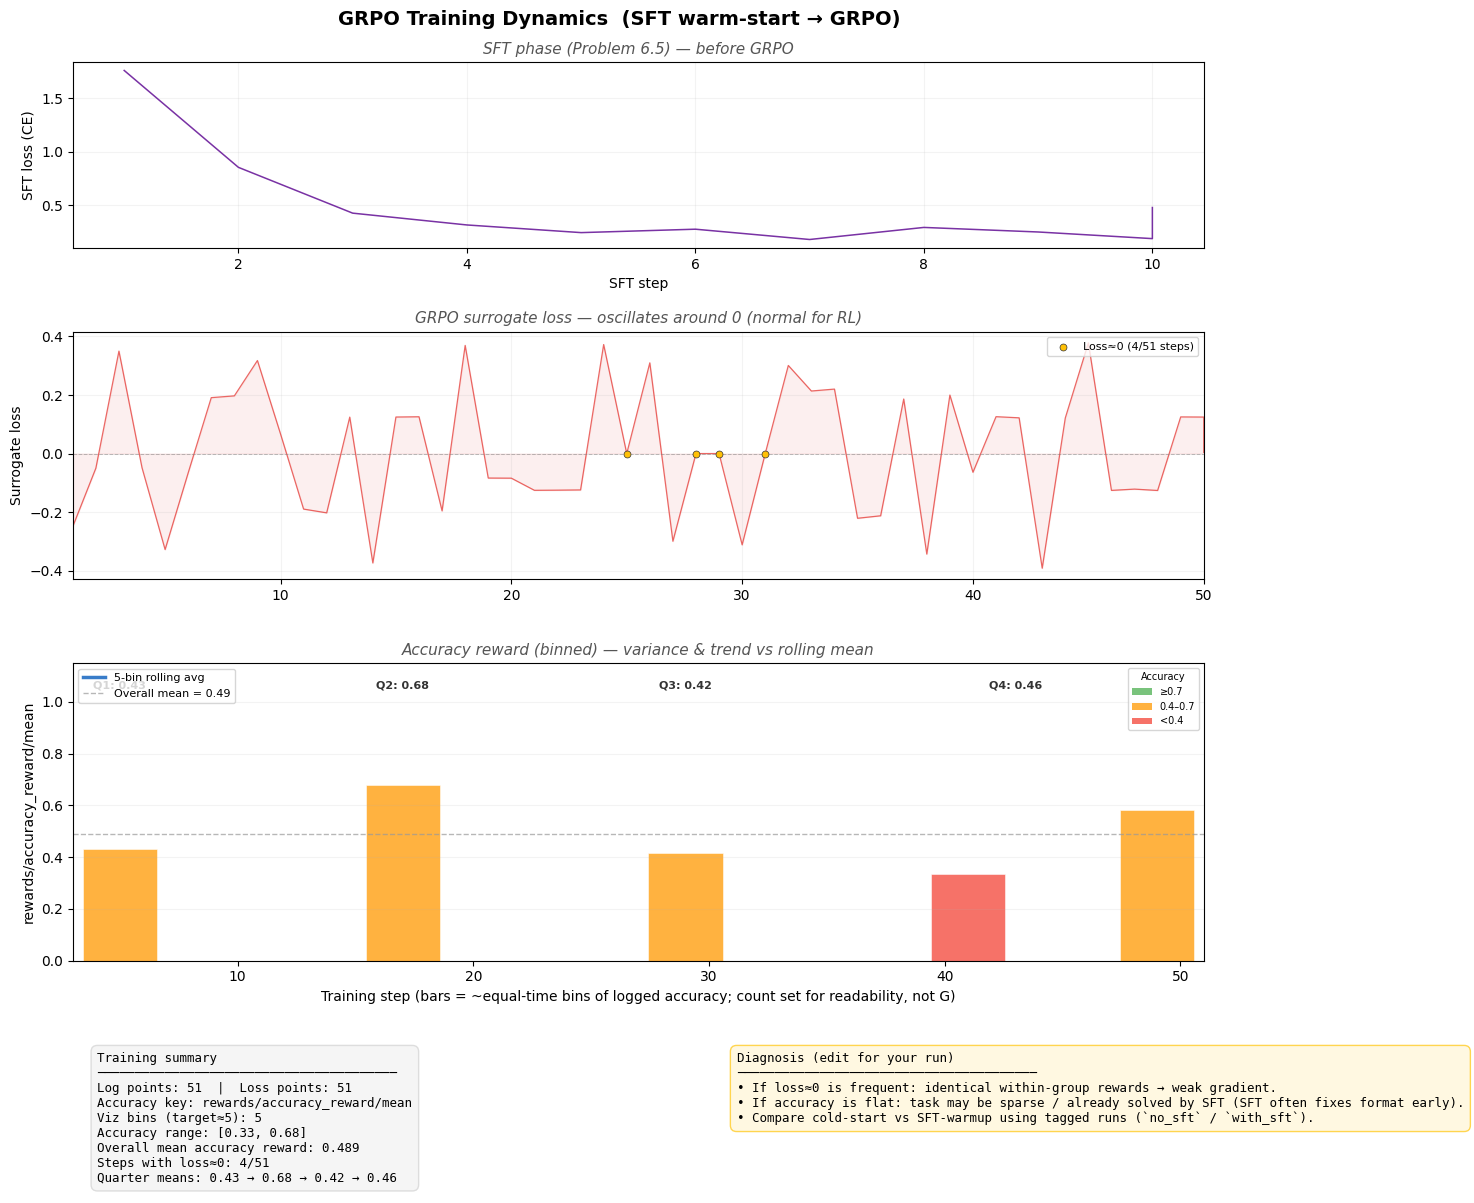

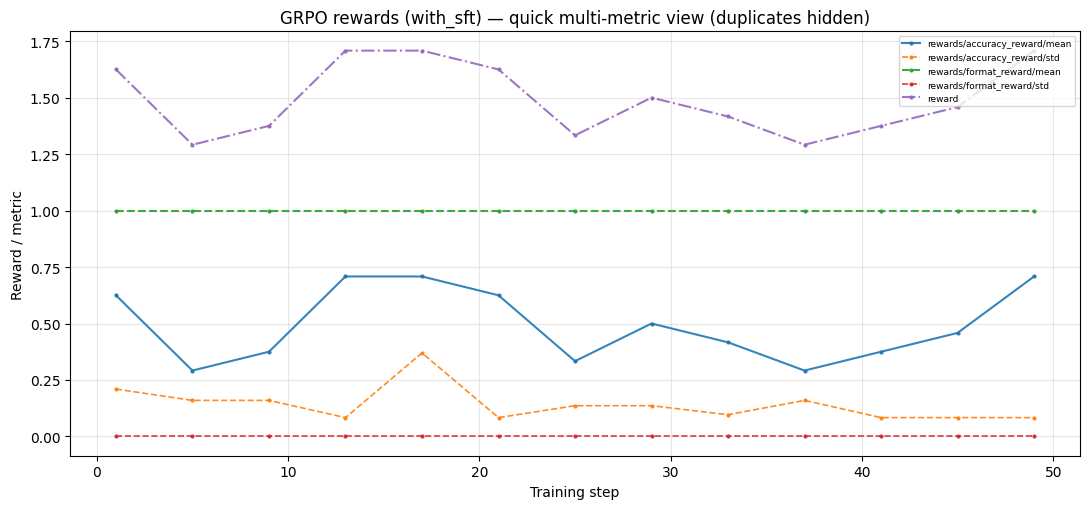

In [14]:
# Problem 7 (continued): GRPO training visualization & analysis
# Priority: (1) trainer.state.log_history (2) grpo_log_history_<tag>.json — reproducible without trainer
from __future__ import annotations

import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from matplotlib.patches import Patch

if "RUN_DATA_DIR" not in globals():
    RUN_DATA_DIR = Path("hw4_run_data") / (
        "cold_grpo"
        if not globals().get("USE_SFT", False)
        else (
            "sft_only"
            if globals().get("SFT_ONLY_BASELINE_RUN", False)
            else "sft_then_grpo"
        )
    )
    RUN_DATA_DIR.mkdir(parents=True, exist_ok=True)
else:
    RUN_DATA_DIR = Path(RUN_DATA_DIR)
_tag = globals().get("GRPO_ARTIFACT_TAG", "no_sft")
_log_path = RUN_DATA_DIR / f"grpo_log_history_{_tag}.json"
_sft_path = RUN_DATA_DIR / "sft_log_history.json"
_sft_hist: list[dict] = []
if _sft_path.is_file():
    _sft_hist = json.loads(_sft_path.read_text(encoding="utf-8"))
    print(f"Loaded SFT log: {_sft_path} ({len(_sft_hist)} entries)")

hist: list[dict] = []
_tr = globals().get("trainer")
if _tr is not None and getattr(getattr(_tr, "state", None), "log_history", None):
    hist = list(_tr.state.log_history)
    _log_path.write_text(json.dumps(hist, indent=2), encoding="utf-8")
    print(f"Saved training log: {_log_path}")
elif _log_path.is_file():
    hist = json.loads(_log_path.read_text(encoding="utf-8"))
    print(f"Loaded log_history from {_log_path} (trainer not in session — OK for reports).")
else:
    hist = []

display(
    Markdown(
        "**How to read this:** RL surrogate **loss** oscillates in GRPO; judge progress mainly from **reward** "
        "metrics. **Loss = 0** often means identical rewards within a group → **zero advantage** → no gradient."
    )
)

_sft_only_mode = bool(globals().get("SFT_ONLY_BASELINE_RUN", False))
if not hist:
    if _sft_only_mode:
        display(
            Markdown(
                "**SFT-only baseline run (`SFT_ONLY_BASELINE_RUN=True`):** Problem 7 GRPO was skipped on purpose. "
                "Use **Problem 8.2 (continued)** with the SFT adapter under this run's `hw4_run_data/.../sft-output/`. "
                f"For GRPO logs/plots (`{_log_path.name}`), set `SFT_ONLY_BASELINE_RUN=False` and re-run Problem 7."
            )
        )
    else:
        display(
            Markdown(
                f"**No log found.** Run Problem 7 first, or add `{_log_path.name}` under RUN_DATA_DIR."
            )
        )
else:

    def _step_key(rows: list[dict]) -> str | None:
        for k in ("step", "global_step"):
            if rows and k in rows[0]:
                return k
        for r in rows:
            for k in ("step", "global_step"):
                if k in r:
                    return k
        return None

    def _loss_val(row: dict) -> float | None:
        for k in ("loss", "train_loss"):
            v = row.get(k)
            if isinstance(v, (int, float)) and not isinstance(v, bool):
                return float(v)
        return None

    def _pick_accuracy_key(rows: list[dict], step_key: str | None) -> str | None:
        best = None
        for r in rows:
            for k, v in r.items():
                if step_key and k == step_key:
                    continue
                if not isinstance(v, (int, float)) or isinstance(v, bool):
                    continue
                kl = k.lower()
                if "reward" not in kl:
                    continue
                if kl in ("reward_std", "frac_reward_zero_std"):
                    continue
                if "accuracy" in kl:
                    return k
                if best is None:
                    best = k
        return best

    sk = _step_key(hist)
    if not sk:
        print("log_history has no step/global_step — cannot plot.")
    else:
        # Per-step loss
        steps_loss: list[int] = []
        losses: list[float] = []
        for r in hist:
            if sk not in r:
                continue
            lv = _loss_val(r)
            if lv is None:
                continue
            steps_loss.append(int(r[sk]))
            losses.append(lv)

        acc_key = _pick_accuracy_key(hist, sk)
        steps_acc: list[int] = []
        acc_vals: list[float] = []
        if acc_key:
            for r in hist:
                if sk not in r or acc_key not in r:
                    continue
                v = r[acc_key]
                if isinstance(v, (int, float)) and not isinstance(v, bool):
                    steps_acc.append(int(r[sk]))
                    acc_vals.append(float(v))

        # Binned bars: ~5–12 equal **sample** bins across logged steps (do NOT use G=NUM_GENERATIONS as bin width —
        # that yields only a few bars when step≈51 and G=4, which misreads as "3 questions" vs many time steps).
        mean_acc: list[float] = []
        unique_steps: list[int] = []
        n_bins_viz = 0
        if acc_vals:
            n_acc = len(acc_vals)
            n_bins_viz = int(min(12, max(5, round(n_acc / 6))))
            splits = np.array_split(np.arange(n_acc), n_bins_viz)
            for part in splits:
                if len(part) == 0:
                    continue
                chunk_a = [acc_vals[j] for j in part]
                chunk_s = [steps_acc[j] for j in part]
                unique_steps.append(int(chunk_s[len(chunk_s) // 2]))
                mean_acc.append(float(np.mean(chunk_a)))

        sft_steps_loss: list[int] = []
        sft_losses: list[float] = []
        if _sft_hist:
            sk_s = _step_key(_sft_hist)
            if sk_s:
                for r in _sft_hist:
                    if sk_s not in r:
                        continue
                    lv = _loss_val(r)
                    if lv is not None:
                        sft_steps_loss.append(int(r[sk_s]))
                        sft_losses.append(lv)

        warm = _tag == "with_sft"
        title_main = (
            f"GRPO Training Dynamics  ({'SFT warm-start → GRPO' if warm else 'cold-start LoRA → GRPO'})"
        )

        _has_sft_plot = bool(sft_steps_loss)
        if _has_sft_plot:
            fig = plt.figure(figsize=(13, 13))
            gs = fig.add_gridspec(4, 2, height_ratios=[0.75, 1, 1.2, 0.6], hspace=0.38, wspace=0.30,
                                  left=0.08, right=0.95, top=0.93, bottom=0.06)
        else:
            fig = plt.figure(figsize=(13, 11))
            gs = fig.add_gridspec(3, 2, height_ratios=[1, 1.2, 0.6], hspace=0.38, wspace=0.30,
                                  left=0.08, right=0.95, top=0.93, bottom=0.06)
        fig.suptitle(title_main, fontsize=14, fontweight="bold", y=0.97)

        r_grpo = 1 if _has_sft_plot else 0
        if _has_sft_plot:
            ax0 = fig.add_subplot(gs[0, :])
            ax0.plot(sft_steps_loss, sft_losses, color="#6A1B9A", linewidth=1.1, alpha=0.9)
            ax0.set_ylabel("SFT loss (CE)")
            ax0.set_xlabel("SFT step")
            ax0.set_title("SFT phase (Problem 6.5) — before GRPO", fontsize=11, style="italic", color="#555")
            ax0.grid(True, alpha=0.15)

        # Panel 1: GRPO Loss
        ax1 = fig.add_subplot(gs[r_grpo, :])
        if steps_loss:
            ax1.plot(steps_loss, losses, color="#E53935", linewidth=0.9, alpha=0.75)
            ax1.axhline(0, color="gray", ls="--", lw=0.7, alpha=0.5)
            ax1.fill_between(steps_loss, losses, 0, alpha=0.08, color="#E53935")
            ax1.set_xlim(min(steps_loss), max(steps_loss))
            lo = min(losses + [0.0])
            hi = max(losses + [0.0])
            pad = 0.05 * (hi - lo + 1e-9)
            ax1.set_ylim(lo - pad, hi + pad)
            zero_steps = [s for s, l in zip(steps_loss, losses) if abs(l) < 1e-4]
            ax1.scatter(
                zero_steps,
                [0] * len(zero_steps),
                color="#FFC107",
                s=25,
                zorder=5,
                label=f"Loss≈0 ({len(zero_steps)}/{len(steps_loss)} steps)",
                edgecolors="#333",
                linewidth=0.5,
            )
            ax1.legend(fontsize=8, loc="upper right")
        ax1.set_ylabel("Surrogate loss")
        ax1.set_title(
            "GRPO surrogate loss — oscillates around 0 (normal for RL)",
            fontsize=11,
            style="italic",
            color="#555",
        )
        ax1.grid(True, alpha=0.15)

        # Panel 2: Accuracy bars
        ax2 = fig.add_subplot(gs[r_grpo + 1, :])
        if mean_acc and unique_steps:
            width = max(0.8, (max(unique_steps) - min(unique_steps) + 1) / max(len(unique_steps), 1) * 0.35)
            colors = ["#4CAF50" if a >= 0.7 else "#FF9800" if a >= 0.4 else "#F44336" for a in mean_acc]
            ax2.bar(unique_steps, mean_acc, width=width, color=colors, alpha=0.75, edgecolor="white", linewidth=0.5)
            window = min(5, len(mean_acc))
            if window >= 2:
                rolling = np.convolve(mean_acc, np.ones(window) / window, mode="valid")
                mid = window // 2
                rolling_x = unique_steps[mid : mid + len(rolling)]
                ax2.plot(
                    rolling_x,
                    rolling,
                    color="#1565C0",
                    linewidth=2.5,
                    alpha=0.85,
                    label=f"{window}-bin rolling avg",
                    zorder=5,
                )
            overall = float(np.mean(mean_acc))
            ax2.axhline(overall, color="#999", ls="--", lw=1, alpha=0.7, label=f"Overall mean = {overall:.2f}")
            smin, smax = min(unique_steps), max(unique_steps)
            # Q1–Q4: quartiles of **per-step** accuracy (time), not of bar bins — always 4 labels when enough points
            if len(acc_vals) >= 4:
                order = np.argsort(np.array(steps_acc, dtype=float))
                s_sorted = [steps_acc[int(i)] for i in order]
                v_sorted = [acc_vals[int(i)] for i in order]
                n = len(v_sorted)
                for qi, ql in enumerate(["Q1", "Q2", "Q3", "Q4"]):
                    i0 = qi * n // 4
                    i1 = (qi + 1) * n // 4 if qi < 3 else n
                    chunk = v_sorted[i0:i1]
                    xs = s_sorted[i0:i1]
                    if not chunk:
                        continue
                    cx = float(np.mean(xs)) if xs else (smin + smax) / 2
                    ax2.annotate(
                        f"{ql}: {float(np.mean(chunk)):.2f}",
                        xy=(cx, 1.05),
                        fontsize=8,
                        ha="center",
                        color="#333",
                        fontweight="bold",
                    )
            ax2.set_xlim(smin - 2, smax + 2)
            ax2.set_ylim(0, 1.15)
            ax2.set_ylabel(acc_key or "Accuracy reward")
            leg1 = ax2.legend(fontsize=8, loc="upper left")
            ax2.add_artist(leg1)
            ax2.legend(
                handles=[
                    Patch(fc="#4CAF50", alpha=0.75, label="≥0.7"),
                    Patch(fc="#FF9800", alpha=0.75, label="0.4–0.7"),
                    Patch(fc="#F44336", alpha=0.75, label="<0.4"),
                ],
                fontsize=7,
                loc="upper right",
                title="Accuracy",
                title_fontsize=7,
            )
            ax2.set_title(
                "Accuracy reward (binned) — variance & trend vs rolling mean",
                fontsize=11,
                style="italic",
                color="#555",
            )
        else:
            ax2.text(0.5, 0.5, "No accuracy reward series found in log.", ha="center", va="center")
        ax2.set_xlabel(
            "Training step (bars = ~equal-time bins of logged accuracy; count set for readability, not G)"
        )
        ax2.grid(True, alpha=0.15, axis="y")

        # Panel 3: Text boxes
        ax3l = fig.add_subplot(gs[r_grpo + 2, 0])
        ax3l.axis("off")
        ax3r = fig.add_subplot(gs[r_grpo + 2, 1])
        ax3r.axis("off")
        overall = float(np.mean(mean_acc)) if mean_acc else float("nan")
        zcount = len([s for s, l in zip(steps_loss, losses) if abs(l) < 1e-4]) if steps_loss else 0
        q_means = []
        if acc_vals and len(acc_vals) >= 4:
            order = np.argsort(np.array(steps_acc, dtype=float))
            v_sorted = [acc_vals[int(i)] for i in order]
            n = len(v_sorted)
            for qi in range(4):
                i0 = qi * n // 4
                i1 = (qi + 1) * n // 4 if qi < 3 else n
                chunk = v_sorted[i0:i1]
                q_means.append(float(np.mean(chunk)) if chunk else 0.0)
        fmt_note = " (SFT often fixes format early)" if warm else ""

        ax3l.text(
            0.05,
            0.95,
            "Training summary\n"
            + "─" * 40
            + f"\nLog points: {len(hist)}  |  Loss points: {len(steps_loss)}"
            + (f"\nAccuracy key: {acc_key}" if acc_key else "\nAccuracy key: (none)")
            + f"\nViz bins (target≈{n_bins_viz}): {len(mean_acc)}"
            + (f"\nAccuracy range: [{min(mean_acc):.2f}, {max(mean_acc):.2f}]" if mean_acc else "")
            + (f"\nOverall mean accuracy reward: {overall:.3f}" if not math.isnan(overall) else "")
            + f"\nSteps with loss≈0: {zcount}/{len(steps_loss) if steps_loss else 0}"
            + (
                f"\nQuarter means: {' → '.join(f'{q:.2f}' for q in q_means)}"
                if len(q_means) == 4
                else ""
            ),
            transform=ax3l.transAxes,
            fontsize=9,
            family="monospace",
            va="top",
            bbox=dict(boxstyle="round,pad=0.5", fc="#F5F5F5", ec="#DDD"),
        )

        diag = (
            "Diagnosis (edit for your run)\n"
            + "─" * 40
            + "\n• If loss≈0 is frequent: identical within-group rewards → weak gradient.\n"
            + "• If accuracy is flat: task may be sparse / already solved by SFT"
            + fmt_note
            + ".\n"
            + "• Compare cold-start vs SFT-warmup using tagged runs (`no_sft` / `with_sft`)."
        )
        ax3r.text(
            0.05,
            0.95,
            diag,
            transform=ax3r.transAxes,
            fontsize=9,
            family="monospace",
            va="top",
            bbox=dict(boxstyle="round,pad=0.5", fc="#FFF8E1", ec="#FFD54F"),
        )

        _out = RUN_DATA_DIR / f"grpo_training_analysis_{_tag}.png"
        plt.savefig(_out, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved: {_out}")

        # Compact multi-metric plot (legacy filename for Drive / checklist)
        reward_keys = []
        for r in hist:
            for k, v in r.items():
                if sk and k == sk:
                    continue
                if not isinstance(v, (int, float)) or isinstance(v, bool):
                    continue
                kl = k.lower()
                if "reward" in kl and k not in reward_keys:
                    reward_keys.append(k)

        def _series_for_key(k: str) -> tuple[list[int], np.ndarray]:
            xs: list[int] = []
            ys: list[float] = []
            for r in hist:
                if sk not in r or k not in r:
                    continue
                v = r[k]
                if isinstance(v, (int, float)) and not isinstance(v, bool):
                    xs.append(int(r[sk]))
                    ys.append(float(v))
            return xs, np.array(ys, dtype=float)

        if sk and reward_keys:
            # Build series; drop curves identical to another (e.g. reward_std == accuracy_reward/std → hide reward_std)
            series: list[tuple[str, list[int], np.ndarray]] = []
            for k in reward_keys:
                xs, ys = _series_for_key(k)
                if len(xs) == 0:
                    continue
                series.append((k, xs, ys))

            drop: set[str] = set()
            for i, (k1, _, y1) in enumerate(series):
                for j, (k2, _, y2) in enumerate(series):
                    if i >= j:
                        continue
                    if y1.shape != y2.shape:
                        continue
                    if not np.allclose(y1, y2, rtol=0, atol=1e-6):
                        continue
                    k1l, k2l = k1.lower(), k2.lower()
                    if k1l == "reward_std" or k1l.endswith("/reward_std"):
                        drop.add(k1)
                    elif k2l == "reward_std" or k2l.endswith("/reward_std"):
                        drop.add(k2)
                    elif "accuracy" in k1l and "std" in k1l:
                        drop.add(k2)
                    else:
                        drop.add(k2)

            fig2, ax = plt.subplots(figsize=(11, 5.2))
            styles = ["-", "-", "--", ":", "-.", (0, (3, 1, 1, 1))]
            plotted = 0
            for k, xs, ys in series:
                if k in drop:
                    continue
                ls = "--" if "std" in k.lower() else styles[plotted % len(styles)]
                lw = 1.2 if "std" in k.lower() else 1.5
                ax.plot(xs, ys, label=k, marker="o", markersize=2, linewidth=lw, linestyle=ls, alpha=0.9)
                plotted += 1
                if plotted >= 8:
                    break
            ax.set_xlabel("Training step")
            ax.set_ylabel("Reward / metric")
            ax.set_title(f"GRPO rewards ({_tag}) — quick multi-metric view (duplicates hidden)")
            ax.legend(loc="best", fontsize=6.5)
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            _simple = RUN_DATA_DIR / f"grpo_reward_curves_{_tag}.png"
            plt.savefig(_simple, dpi=150, bbox_inches="tight")
            plt.show()
            print(f"Saved: {_simple}")


In [ ]:
# Curation note
# Drive checkpoint synchronization and directory replacement are omitted because they are local checkpoint material.


# **Questions to answer:**

1. Report the hyperparameter settings you used to get the best model. How did the reward values change over training?

2. Compare the training dynamics of GRPO (this homework) with SFT/LoRA (HW3). Which converged faster, and which produced better results on your dataset?


Please see the report of the homework.


# Problem 8: Post-Training Evaluation (20 points)

## Problem 8.1 Load the Trained Model

Load the GRPO-trained LoRA adapters onto the base model for inference.

In [ ]:
from pathlib import Path
import torch
from peft import PeftModel
from transformers import AutoProcessor, AutoModelForImageTextToText

import os

_DRIVE_QWEN_CACHE = Path("<Google Drive path removed>")
MODEL_ID = (
    str(_DRIVE_QWEN_CACHE)
    if _DRIVE_QWEN_CACHE.is_dir()
    else os.environ.get('QWEN3_VL_MODEL_ID', 'Qwen/Qwen3-VL-2B-Instruct')
)
# Default: Hugging Face Hub (graders). Colab: auto-uses Drive folder if present. Override: export QWEN3_VL_MODEL_ID=/path/to/model
OUTPUT_DIR = globals().get("OUTPUT_DIR")
if OUTPUT_DIR is None:
    _tag = "with_sft" if globals().get("USE_SFT", False) else "no_sft"
    _rd = Path(globals().get("RUN_DATA_DIR", Path("hw4_run_data") / ("cold_grpo" if _tag == "no_sft" else "sft_then_grpo")))
    OUTPUT_DIR = str(_rd / f"grpo-output_{_tag}")

_tag = "with_sft" if globals().get("USE_SFT", False) else "no_sft"
_grpo_name = f"grpo-output_{_tag}"
_primary = Path(OUTPUT_DIR)
_candidates = [
    _primary,
    Path("hw4_run_data") / "sft_then_grpo" / _grpo_name,
    Path("hw4_run_data") / "cold_grpo" / _grpo_name,
    Path(_grpo_name),
]
_ckpt = next((p for p in _candidates if p.is_dir()), None)
if _ckpt is None:
    _tried = ", ".join(str(p) for p in _candidates)

    processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)

    if globals().get("SFT_ONLY_BASELINE_RUN", False):
        print(
            "SFT-only baseline session: no GRPO adapter (Problem 7 was skipped). "
            "Skipping GRPO load. Problem 8.2 GRPO loop will be skipped; run Problem 8.2 (continued) for "
            "zero-shot + SFT-only baselines.\n"
            f"Tried: {_tried}"
        )
        ft_model = None
        globals()["SKIP_GRPO_82"] = True
    else:
        raise FileNotFoundError(
            f"Missing GRPO adapter. Tried: {_tried}. Run Problem 7 training (save_model) first."
        )
else:
    if _ckpt.resolve() != _primary.resolve():
        print(
            f"Using GRPO checkpoint: {_ckpt} (primary {_primary} not found — e.g. after an SFT-only baseline run)."
        )
    OUTPUT_DIR = str(_ckpt)

    processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)

    base_model = AutoModelForImageTextToText.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.bfloat16,
        device_map="auto",
        trust_remote_code=True,
    )

    ft_model = PeftModel.from_pretrained(base_model, OUTPUT_DIR)
    ft_model.eval()
    globals()["SKIP_GRPO_82"] = False
    print("GRPO-trained model loaded. Ready for inference.")


## Problem 8.2: Test on Held-Out Images (15 points)

Test the GRPO-trained model on your held-out test images. If `mmai-data/data_test.jsonl` exists (HW3 split), the code cell **loads up to `MAX_TEST_SAMPLES` rows** with local image paths; otherwise it uses the built-in COCO URL demos.

For each test image, the cell will:
1. Run inference with the same instruction suffix used during training
2. Extract the answer from after `Answer:`
3. Compare to ground truth

In [17]:
import io
import json
import torch
import requests
from pathlib import Path
from PIL import Image
from IPython.display import display

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================

DATA_ROOT = Path("mmai-data")
# Prefer HW3-style held-out split (same folder as training images)
USE_MMAI_TEST_JSONL = True
MAX_TEST_SAMPLES = 8  # None = use all rows in data_test.jsonl

# If data_test.jsonl is missing, these COCO demos are used instead
TEST_SAMPLES_FALLBACK = [
    {
        "image": "http://images.cocodataset.org/val2017/000000039769.jpg",
        "question": "What is the main object in this image?",
        "answer": "cat",
    },
    {
        "image": "http://images.cocodataset.org/val2017/000000001532.jpg",
        "question": "What is the main object in this image?",
        "answer": "truck",
    },
]

MAX_NEW_TOKENS = 512

# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================


def _load_test_samples() -> list:
    """Build test list from data_test.jsonl (paths under DATA_ROOT) or fall back to URLs."""
    test_path = DATA_ROOT / "data_test.jsonl"
    if USE_MMAI_TEST_JSONL and test_path.is_file():
        rows = []
        with open(test_path, encoding="utf-8") as f:
            for line in f:
                if line.strip():
                    rows.append(json.loads(line))
        if MAX_TEST_SAMPLES is not None:
            rows = rows[:MAX_TEST_SAMPLES]
        out = []
        for r in rows:
            img_path = DATA_ROOT / r["image"]
            if not img_path.is_file():
                print(f"Skip (missing file): {img_path}")
                continue
            out.append(
                {
                    "image": str(img_path.resolve()),
                    "question": r["question"],
                    "answer": r["answer"],
                }
            )
        if out:
            print(f"Using {len(out)} held-out samples from {test_path.name}")
            return out
        print("data_test.jsonl produced no valid rows; using fallback demos.")
    else:
        print("Using fallback COCO demo samples (set up mmai-data/data_test.jsonl for your split).")
    return list(TEST_SAMPLES_FALLBACK)


TEST_SAMPLES = _load_test_samples()
if not TEST_SAMPLES:
    raise RuntimeError("No test samples — check data_test.jsonl / image paths or fallback URLs.")

# Must match Problem 6 instruction suffix (training / eval alignment)
INSTRUCTION_SUFFIX = (
    "\n\nBefore providing your final answer, you MUST write down your visual reasoning step-by-step. "
    "Look at the provided MILP heatmap and explicitly answer these five questions:\n"
    "1. Variables: Count individual blocks or columns along the X-axis (horizontal) in the main matrix — what is "
    "the total number of variables? Cross-check tick marks or labels if visible.\n"
    "2. Constraints: Count individual blocks or rows along the Y-axis (vertical) in the main matrix — what is the "
    "total number of constraints?\n"
    "3. Density: Look at the overall main matrix grid. From colored blocks versus empty space, is density low, medium, or high?\n"
    "4. Variable types: Look at the bottom row labeled 'vtype' and its legend. From the colors shown, estimate "
    "the percentage of Binary variables and Integer variables.\n"
    "5. Objective: Look at the rightmost section (e.g. inequality signs <=, >=, or == next to 'coefficient of obj'). "
    "Is it minimize or maximize?\n\n"
    "After all five steps, output exactly ONE final line. It must start with \"Answer:\" and then use the "
    "SAME format as the dataset answer field (the text after \"Answer:\" must look like: "
    "Variables: <int>, Constraints: <int>, Density: low|medium|high, Binary: <int>%, Integer: <int>%, Objective: minimize|maximize).\n"
    "Pattern example (illustrative numbers only — yours must match the image):\n"
    "Answer: Variables: 4, Constraints: 5, Density: high, Binary: 0%, Integer: 50%, Objective: minimize\n"
    "Full example — reasoning lines, then the final line repeated in that exact answer format:\n"
    "1. Variables: I count 4 variable columns along the X-axis in the main matrix.\n"
    "2. Constraints: I count 5 constraint rows along the Y-axis.\n"
    "3. Density: most cells are nonzero — high.\n"
    "4. Variable types: from the vtype row and legend I estimate Binary 0% and Integer 50%.\n"
    "5. Objective: the objective / coefficient-of-obj inequalities indicate minimize.\n"
    "Answer: Variables: 4, Constraints: 5, Density: high, Binary: 0%, Integer: 50%, Objective: minimize"
)

def load_image(source: str) -> Image.Image:
    """Load image from a local path or URL."""
    if source.startswith("http://") or source.startswith("https://"):
        response = requests.get(source, stream=True)
        return Image.open(io.BytesIO(response.content)).convert("RGB")
    else:
        return Image.open(source).convert("RGB")

results = []

_skip_grpo = bool(globals().get("SKIP_GRPO_82", False))
if _skip_grpo or ft_model is None:
    print(
        "Skipping Problem 8.2 GRPO test loop (no GRPO checkpoint in this session). "
        "Run Problem 8.2 (continued) for zero-shot + SFT-only baselines."
    )

for sample in TEST_SAMPLES:
    if _skip_grpo or ft_model is None:
        continue
    try:
        image = load_image(sample["image"])
    except Exception as e:
        print(f"Could not load image {sample['image']}: {e}")
        continue

    messages = [
        {"role": "user", "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": sample["question"] + INSTRUCTION_SUFFIX},
        ]},
    ]

    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(images=[image], text=[text], return_tensors="pt", padding=True).to(ft_model.device)

    with torch.no_grad():
        output_ids = ft_model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS, temperature=0.7, do_sample=True)

    generated = processor.decode(output_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    extracted = extract_answer(generated)

    field_hits = milp_per_field_correct(extracted, sample["answer"])
    exact = (extracted is not None) and (
        " ".join(extracted.lower().split()) == " ".join(sample["answer"].lower().split())
    )
    results.append({
        "image": sample["image"],
        "question": sample["question"],
        "model_output": generated,
        "extracted_answer": extracted,
        "ground_truth": sample["answer"],
        "correct": exact,
        "has_format": extracted is not None,
        "field_hits": field_hits,
        "partial_score": (sum(field_hits) / 6.0) if field_hits else None,
    })

    display(image.resize((256, 256)))
    print(f"Question: {sample['question']}")
    print(f"Model output: {generated}")
    print(f"Extracted: {extracted}")
    print(f"Ground truth: {sample['answer']}")
    print(f"Exact match: {results[-1]['correct']} | Format: {results[-1]['has_format']}")
    fh = results[-1]["field_hits"]
    if fh is not None:
        bits = ", ".join(
            f"{MILP_FIELD_NAMES[i]}:{'OK' if fh[i] else 'X'}" for i in range(6)
        )
        print(f"Per-field: {bits}  ({sum(fh)}/6)")
    else:
        print("Per-field: (skipped — unparsable or non-MILP line)")
    print("-" * 60)

n = len(results)
if n > 0:
    acc = sum(r["correct"] for r in results) / n
    fmt = sum(r["has_format"] for r in results) / n
    print(f"\nSummary: Exact-match accuracy={acc:.1%}, Format compliance={fmt:.1%} ({n} samples)")
    field_correct = [0] * 6
    field_valid = [0] * 6
    for r in results:
        fh = r.get("field_hits")
        if not fh:
            continue
        for i in range(6):
            field_valid[i] += 1
            if fh[i]:
                field_correct[i] += 1
    if any(v > 0 for v in field_valid):
        print("Per-field accuracy (samples where both prediction and ground truth parse as MILP):")
        for i, name in enumerate(MILP_FIELD_NAMES):
            if field_valid[i]:
                print(
                    f"  {name}: {field_correct[i] / field_valid[i]:.1%} ({field_correct[i]}/{field_valid[i]})"
                )
    partials = [r["partial_score"] for r in results if r.get("partial_score") is not None]
    if partials:
        print(f"Mean partial score (mean of per-sample field fraction): {sum(partials) / len(partials):.3f}")


Using 8 held-out samples from data_test.jsonl


Question: Describe the structure of this MILP heatmap: number of variables, number of constraints, matrix density, fraction of binary variables, fraction of integer variables, and objective direction (minimize or maximize).
Model output: Variables: 2, Constraints: 2, Density: high, Binary: 0%, Integer: 100%, Objective: maximize
Extracted: Variables: 2, Constraints: 2, Density: high, Binary: 0%, Integer: 100%, Objective: maximize
Ground truth: Variables: 2, Constraints: 2, Density: high, Binary: 0%, Integer: 100%, Objective: maximize
Exact match: True | Format: True
Per-field: Variables:OK, Constraints:OK, Density:OK, Binary:OK, Integer:OK, Objective:OK  (6/6)
------------------------------------------------------------

Summary: Exact-match accuracy=12.5%, Format compliance=100.0% (8 samples)
Per-field accuracy (samples where both prediction and ground truth parse as MILP):
  Variables: 62.5% (5/8)
  Constraints: 62.5% (5/8)
  Density: 87.5% (7/8)
  Binary: 75.0% (6/8)
  Integer: 62.5%

In [ ]:
# Curation note
# Raw test-image, prompt, model-output, and ground-truth export is omitted from the public artifact.


In [19]:
# Problem 8.2 (continued): base model zero-shot + SFT-only (HW3-style) for 8.3 comparison
# Run after the Problem 8.2 GRPO cell (needs TEST_SAMPLES, INSTRUCTION_SUFFIX, load_image, extract_answer, etc.).

from pathlib import Path

import torch
from peft import PeftModel
from transformers import AutoModelForImageTextToText


def _eval_one_model(model, tag: str) -> list:
    """Same protocol as the GRPO 8.2 loop; returns one dict per successful sample."""
    rows = []
    for sample in TEST_SAMPLES:
        try:
            image = load_image(sample["image"])
        except Exception as e:
            print(f"[{tag}] skip image: {e}")
            continue
        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": image},
                    {"type": "text", "text": sample["question"] + INSTRUCTION_SUFFIX},
                ],
            },
        ]
        text = processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
        inputs = processor(
            images=[image], text=[text], return_tensors="pt", padding=True
        ).to(model.device)
        with torch.no_grad():
            output_ids = model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                temperature=0.7,
                do_sample=True,
            )
        generated = processor.decode(
            output_ids[0][inputs["input_ids"].shape[1] :], skip_special_tokens=True
        )
        extracted = extract_answer(generated)
        field_hits = milp_per_field_correct(extracted, sample["answer"])
        exact = (extracted is not None) and (
            " ".join(extracted.lower().split())
            == " ".join(sample["answer"].lower().split())
        )
        rows.append(
            {
                "tag": tag,
                "model_output": generated,
                "extracted_answer": extracted,
                "ground_truth": sample["answer"],
                "correct": exact,
                "has_format": extracted is not None,
                "partial_score": (sum(field_hits) / 6.0) if field_hits else None,
            }
        )
    return rows


def _print_summary(rows: list, label: str) -> None:
    n = len(rows)
    if n == 0:
        print(f"{label}: no results")
        return
    acc = sum(r["correct"] for r in rows) / n
    fmt = sum(r["has_format"] for r in rows) / n
    partials = [r["partial_score"] for r in rows if r.get("partial_score") is not None]
    mp = sum(partials) / len(partials) if partials else float("nan")
    print(f"{label} — n={n} exact={acc:.1%} format={fmt:.1%} mean_partial={mp:.3f}")


# --- Base Qwen3-VL-2B (no LoRA): zero-shot ---
_base_z = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True,
)
_base_z.eval()
base_zero_rows = _eval_one_model(_base_z, "base_zero")
_print_summary(base_zero_rows, "Base (zero-shot, no adapters)")
del _base_z
torch.cuda.empty_cache()

# --- SFT-only checkpoint (Problem 6.5), if present ---
_sft_dir = Path(globals().get("RUN_DATA_DIR", Path("."))) / "sft-output"
if _sft_dir.is_dir() and (_sft_dir / "adapter_config.json").is_file():
    _bm = AutoModelForImageTextToText.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.bfloat16,
        device_map="auto",
        trust_remote_code=True,
    )
    _sft_m = PeftModel.from_pretrained(_bm, str(_sft_dir))
    _sft_m.eval()
    sft_only_rows = _eval_one_model(_sft_m, "sft_only")
    _print_summary(sft_only_rows, "SFT-only LoRA (sft-output/, no GRPO)")
    del _sft_m
    del _bm
    torch.cuda.empty_cache()
else:
    print("Skip SFT-only eval: no adapter at sft-output/ (run Problem 6.5 or copy HW3 adapter).")
    sft_only_rows = []

EVAL_BASELINE_FOR_REPORT = {"base_zero": base_zero_rows, "sft_only": sft_only_rows}
print("Stored in EVAL_BASELINE_FOR_REPORT — paste metrics / excerpts into the Word report.")

# Export rows for generate_report_hw4_v2.py (place under report_snippets/ or sync from Drive)
import json as _json
_out_dirs = [
    Path("report_snippets"),
    Path("<Google Drive path removed>"),
    Path("<local path removed>"),
]
for _d in _out_dirs:
    try:
        _d.mkdir(parents=True, exist_ok=True)
        _fp = _d / "eval_baseline_rows.json"
        _fp.write_text(
            _json.dumps(EVAL_BASELINE_FOR_REPORT, indent=2, ensure_ascii=False),
            encoding="utf-8",
        )
        print("Wrote", _fp.resolve())
    except OSError:
        pass



Base (zero-shot, no adapters) — n=8 exact=0.0% format=62.5% mean_partial=0.367


Archived aggregate base-versus-SFT evaluation retained; per-example records and local report exports omitted.


## Problem 8.3: Reflection (5 points)

Compare the GRPO-trained model with the pre-trained base model (zero-shot) and your SFT model from HW3:
- Does the GRPO model use the `Answer:` format more consistently?
- Does it show step-by-step reasoning before the answer?


Please see the report.